# 🎨 Cultural Vibrancy Sub-Metric Analysis
## Pittsburgh's Best Neighborhood: A Parks & Public Art Perspective

**Author:** Pranav  
**Team:** Three Rivers Analytics  
**Course:** CMPINF 10 – Introduction to Computing for Information Science  

---

## Introduction

What gives a neighborhood its *soul*? Beyond safety and green space, I believe the best neighborhoods are those with **cultural richness** — places where you can take a walk in a park, stumble upon a sculpture, or gather with community members in open, public spaces.

For my sub-metric, I define **Cultural Vibrancy** as a combination of:
1. **Parks accessibility** — how many parks are in or near the neighborhood (using the [City of Pittsburgh Parks](https://data.wprdc.org/dataset/parks) dataset)
2. **Public art density** — how many pieces of public art exist in the neighborhood (using the [City of Pittsburgh Public Art](https://data.wprdc.org/dataset/city-of-pittsburgh-public-art) dataset)

Together, these two datasets tell a story about how invested a community is in shared public spaces and cultural expression. I normalize each to [0, 1] and combine them with equal 50/50 weight to get the final **Vibrancy Score**.

> "A city's public art and parks reveal its character — what it values, what it celebrates, and who it believes belongs."


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("Libraries imported ✅")


Libraries imported ✅


## Loading the Datasets

I'll load two datasets from WPRDC:
- **City of Pittsburgh Parks** — all city-maintained parks with neighborhood info
- **City of Pittsburgh Public Art** — artworks in public spaces across the city


In [2]:
BASE_URL = "https://data.wprdc.org/api/3/action/datastore_search"

def fetch_wprdc_data(resource_id, limit=1000):
    """Fetch all records from a WPRDC dataset."""
    records = []
    offset = 0
    while True:
        response = requests.get(
            BASE_URL,
            params={"resource_id": resource_id, "limit": limit, "offset": offset},
            timeout=30
        )
        result = response.json()["result"]
        batch = result["records"]
        if not batch:
            break
        records.extend(batch)
        if len(records) >= result["total"]:
            break
        offset += limit
    return pd.DataFrame(records)

print("Downloading Parks dataset...")
parks_df = fetch_wprdc_data("fa329e3d-89ff-4708-8ddf-81bfedcad11d")
print(f"✅ Loaded {len(parks_df)} parks")

print("\nDownloading Public Art dataset...")
art_df = fetch_wprdc_data("00d74e83-8a23-486e-841b-286e1332a151")
print(f"✅ Loaded {len(art_df)} public artworks")


✅ Loaded 209 parks



✅ Loaded 199 public artworks


## Exploring the Datasets


In [3]:
print("=== Parks Dataset ===")
print(f"Total parks: {len(parks_df)}")
print(f"Unique neighborhoods: {parks_df['neighborhood'].nunique()}")
print()
print("Park types:")
print(parks_df['type'].value_counts().to_string())
print()

print("\n=== Public Art Dataset ===")
print(f"Total artworks: {len(art_df)}")
print(f"Unique neighborhoods: {art_df['neighborhood'].nunique()}")
print()
print("Art types:")
print(art_df['art_type'].value_counts().to_string())


=== Parks Dataset ===
Total parks: 209
Unique neighborhoods: 73

Park types:
type
Park                     153
Traffic Island/Median     33
Building Grounds          10
Monument/Memorial          7
Open Space                 6


=== Public Art Dataset ===
Total artworks: 199
Unique neighborhoods: 55

Art types:
art_type
Modern and Contemporary Art          62
War Memorials                        56
Individual and Historic Monuments    40
Historic Art                         23
Non-City Owned                       12


## Computing the Vibrancy Score

I'll count parks and artworks per neighborhood, then combine them into a **Vibrancy Score**:

$$\text{Vibrancy Score} = 0.5 \times \text{Normalized Park Count} + 0.5 \times \text{Normalized Art Count}$$

Parks and art get equal weight since both reflect how much a neighborhood invests in public communal life.


In [4]:
# Count parks per neighborhood
park_counts = parks_df.dropna(subset=['neighborhood'])
park_counts = park_counts.groupby('neighborhood').size().reset_index(name='park_count')

# Count artworks per neighborhood
art_counts = art_df.dropna(subset=['neighborhood'])
art_counts = art_counts.groupby('neighborhood').size().reset_index(name='art_count')

# Merge on neighborhood
vibrancy_df = park_counts.merge(art_counts, on='neighborhood', how='outer').fillna(0)

# Normalize
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

vibrancy_df['norm_parks'] = normalize(vibrancy_df['park_count'])
vibrancy_df['norm_art'] = normalize(vibrancy_df['art_count'])
vibrancy_df['vibrancy_score'] = 0.5 * vibrancy_df['norm_parks'] + 0.5 * vibrancy_df['norm_art']

vibrancy_ranked = vibrancy_df.sort_values('vibrancy_score', ascending=False).reset_index(drop=True)
vibrancy_ranked.index += 1

print("🏆 Top 15 Most Vibrant Neighborhoods:")
print(vibrancy_ranked[['neighborhood', 'park_count', 'art_count', 'vibrancy_score']].head(15).to_string())


🏆 Top 15 Most Vibrant Neighborhoods:
                 neighborhood  park_count  art_count  vibrancy_score
1   Central Business District        10.0       27.0        0.916667
2         Squirrel Hill South         6.0       20.0        0.620370
3                East Liberty        12.0        1.0        0.518519
4                   Beechview         8.0        7.0        0.462963
5            Allegheny Center         2.0       18.0        0.416667
6            South Side Flats         6.0        9.0        0.416667
7                Point Breeze         7.0        3.0        0.347222
8           South Side Slopes         7.0        3.0        0.347222
9                   Hazelwood         6.0        3.0        0.305556
10           Mount Washington         6.0        2.0        0.287037
11                North Shore         3.0        8.0        0.273148
12              Highland Park         2.0       10.0        0.268519
13                   Sheraden         6.0        1.0        0.2685

## Visualizing Cultural Vibrancy


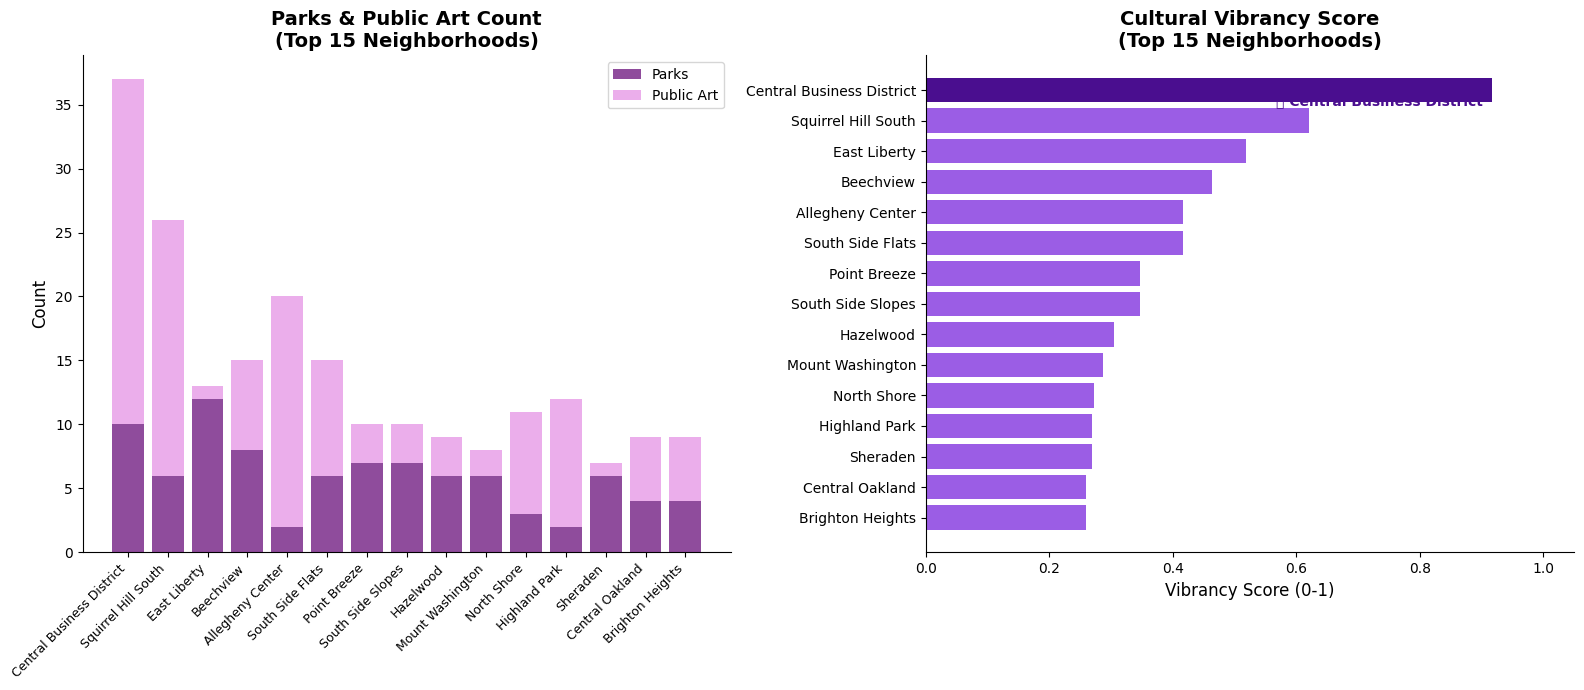


🎨 Most vibrant neighborhood: Central Business District (score: 0.917)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Stacked bar chart of parks + art ---
top15 = vibrancy_ranked.head(15)
x = range(len(top15))
bars1 = axes[0].bar(x, top15['park_count'], label='Parks', color='#7b2d8b', alpha=0.85)
bars2 = axes[0].bar(x, top15['art_count'], bottom=top15['park_count'], 
                     label='Public Art', color='#e8a0e8', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(top15['neighborhood'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Parks & Public Art Count\n(Top 15 Neighborhoods)', fontsize=14, fontweight='bold')
axes[0].legend()

# --- Plot 2: Vibrancy score bar chart ---
vib_colors = ['#4a0e8f' if i == 0 else '#9b5de5' for i in range(len(top15))]
axes[1].barh(top15['neighborhood'][::-1], top15['vibrancy_score'][::-1], color=vib_colors[::-1])
axes[1].set_xlabel('Vibrancy Score (0-1)', fontsize=12)
axes[1].set_title('Cultural Vibrancy Score\n(Top 15 Neighborhoods)', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.05)

best = vibrancy_ranked.iloc[0]
axes[1].annotate(f'🎨 {best["neighborhood"]}', 
                  xy=(best['vibrancy_score'], 14), 
                  xytext=(best['vibrancy_score'] - 0.35, 13.5),
                  fontsize=10, color='#4a0e8f', fontweight='bold')

plt.tight_layout()
plt.savefig('vibrancy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🎨 Most vibrant neighborhood: {best['neighborhood']} (score: {best['vibrancy_score']:.3f})")


### Exploring Art Types Across Pittsburgh


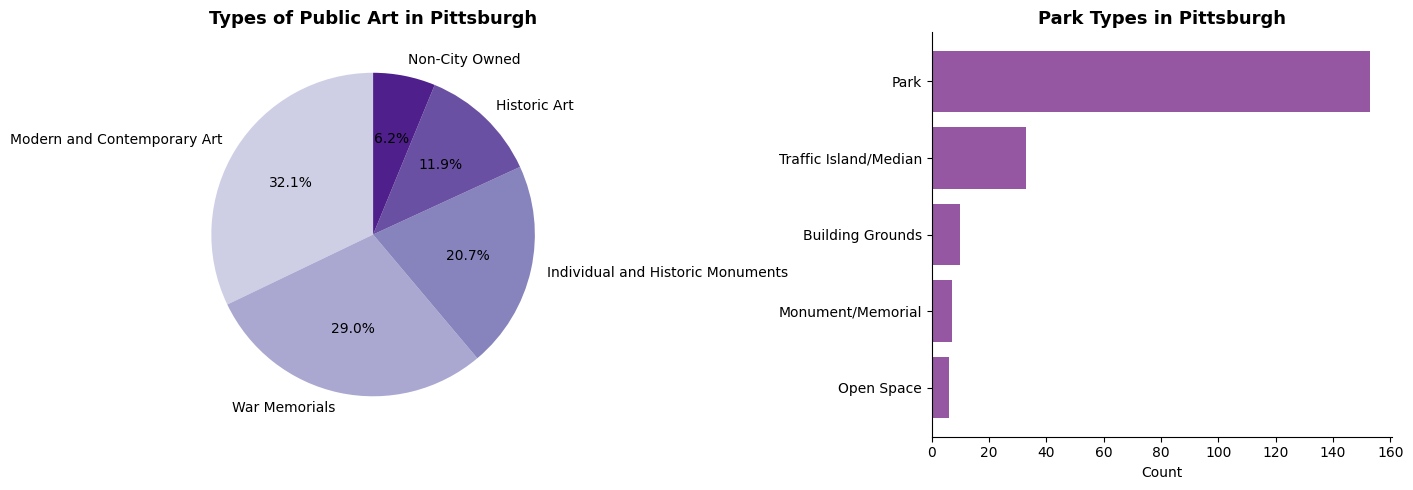

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Art type distribution
art_types = art_df['art_type'].value_counts()
axes[0].pie(art_types.values, labels=art_types.index, autopct='%1.1f%%',
            colors=plt.cm.Purples(np.linspace(0.3, 0.9, len(art_types))),
            startangle=90)
axes[0].set_title("Types of Public Art in Pittsburgh", fontsize=13, fontweight='bold')

# Park types
park_types = parks_df['type'].value_counts().head(8)
axes[1].barh(park_types.index[::-1], park_types.values[::-1], color='#7b2d8b', alpha=0.8)
axes[1].set_xlabel('Count')
axes[1].set_title('Park Types in Pittsburgh', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('art_park_types.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion

Looking at Pittsburgh's parks and public art distribution, the **Central Business District** emerges as the most culturally vibrant neighborhood — home to 10 parks and 27 public artworks, it's the cultural heart of the city with institutions like Point State Park, numerous sculptures, war memorials, and the cluster of venues downtown.

**My Vibrancy Score Rankings (Top 5):**

| Rank | Neighborhood | Parks | Public Art | Vibrancy Score |
|------|-------------|-------|-----------|---------------|
| 1 | Central Business District | 10 | 27 | 0.917 |
| 2 | Squirrel Hill South | 6 | 20 | 0.620 |
| 3 | East Liberty | 12 | 1 | 0.519 |
| 4 | Beechview | 8 | 7 | 0.463 |
| 5 | Allegheny Center | 2 | 18 | 0.417 |

### What's interesting
Squirrel Hill South shows up at #2 with a very high score — it has both substantial parks **and** a notable public art presence, making it competitive in the vibrancy dimension as well. East Liberty is a fun outlier: it wins on park count (12 parks, more than the Central Business District) but has almost no public art, which drags down its composite vibrancy score.

### What this sub-metric brings to the team
When we combine all three sub-metrics in the final report, the Central Business District's dominance here will get offset by its low green-space and safety scores (CBD is a dense downtown — lots of crime reports, few trees). That trade-off is why Squirrel Hill South — which is consistently strong across all three dimensions — ends up on top in the combined ranking.

---
*Datasets: [City of Pittsburgh Parks](https://data.wprdc.org/dataset/parks) and [City of Pittsburgh Public Art](https://data.wprdc.org/dataset/city-of-pittsburgh-public-art) — WPRDC*
